In [19]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [20]:
df = pd.read_csv('tested_titanic.csv', usecols=['Age', 'Fare', 'Survived'])
df.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [14]:
df.isnull().sum()

Survived     0
Age         86
Fare         1
dtype: int64

In [21]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13256\1757650640.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


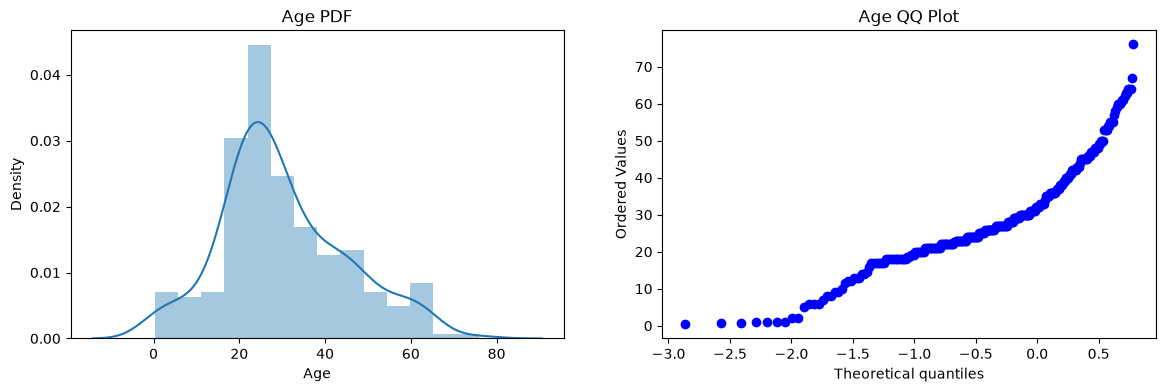

In [22]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_13256\1980004139.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


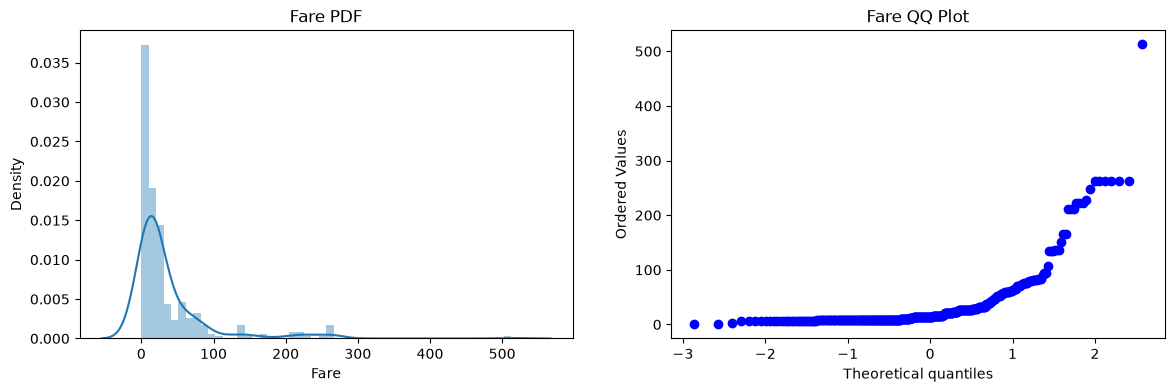

In [23]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()


In [24]:
# Impute NaNs before log transform
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# Apply log transformation
trf = FunctionTransformer(func=np.log1p)
X_train_transformed = trf.fit_transform(X_train_imp)
X_test_transformed = trf.transform(X_test_imp)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)
y_pred2 = clf2.predict(X_test_transformed)

print("Accuracy LR:", accuracy_score(y_test, y_pred))
print("Accuracy DT:", accuracy_score(y_test, y_pred2))

Accuracy LR: 0.6190476190476191
Accuracy DT: 0.5714285714285714


In [28]:
from sklearn.pipeline import make_pipeline

pipe_lr = make_pipeline(
    SimpleImputer(strategy='median'),
    FunctionTransformer(func=np.log1p),
    LogisticRegression()
)

pipe_dt = make_pipeline(
    SimpleImputer(strategy='median'),
    FunctionTransformer(func=np.log1p),
    DecisionTreeClassifier()
)

print("LR Cross-Val Score:", np.mean(cross_val_score(pipe_lr, X, y, scoring='accuracy', cv=10)))
print("DT Cross-Val Score:", np.mean(cross_val_score(pipe_dt, X, y, scoring='accuracy', cv=10)))

LR Cross-Val Score: 0.6532520325203252
DT Cross-Val Score: 0.5979094076655052


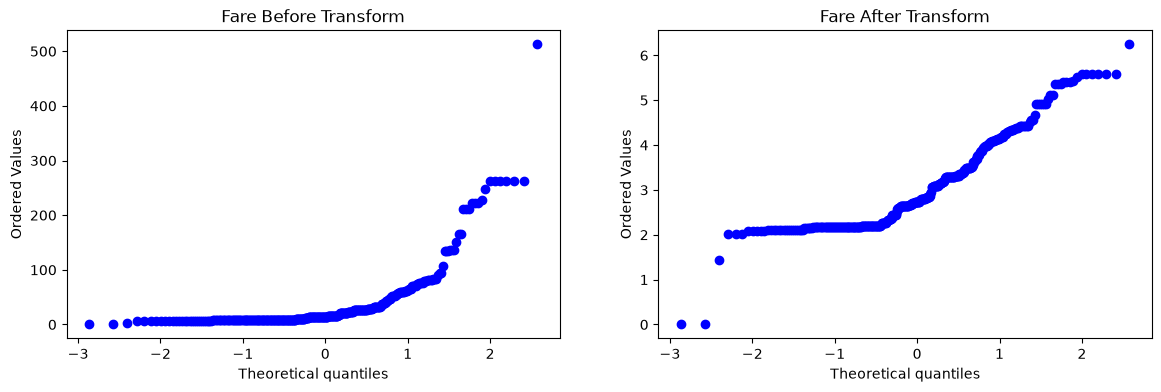

In [29]:
plt.figure(figsize=(14, 4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Transform')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Transform')

plt.show()

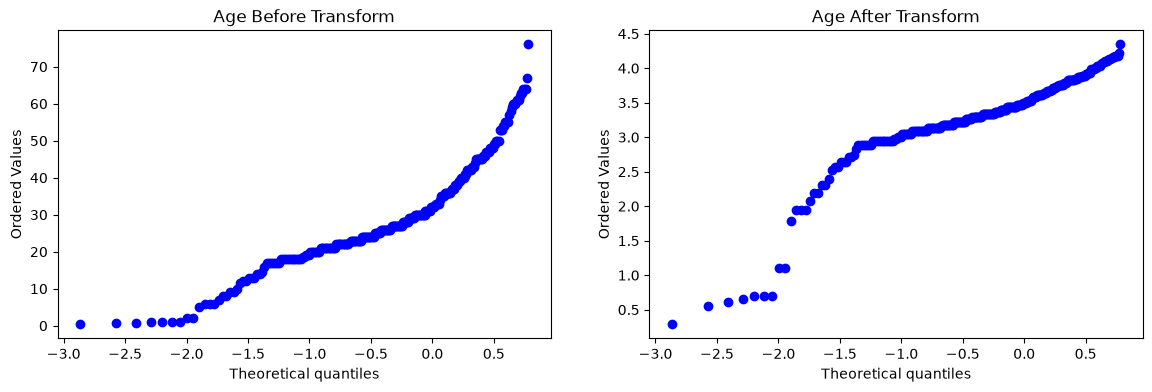

In [30]:
plt.figure(figsize=(14, 4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Transform')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Transform')

plt.show()

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Pipeline for Fare: impute + log transform
fare_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p))
])

# Pipeline for numerical columns with NaNs (like Age)
num_imputer = SimpleImputer(strategy='median')

trf = ColumnTransformer(
    transformers=[
        ('fare_trf', fare_transformer, ['Fare']),
        ('age_impute', num_imputer, ['Age'])
    ],
    remainder='passthrough'
)

# Fit & transform
X_train_transformed2 = trf.fit_transform(X_train)
X_test_transformed2 = trf.transform(X_test)

# Fit models
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR:", accuracy_score(y_test, y_pred))
print("Accuracy DT:", accuracy_score(y_test, y_pred2))

Accuracy LR: 0.6309523809523809
Accuracy DT: 0.5714285714285714


In [35]:
from sklearn.pipeline import make_pipeline

# Create cross-validation pipelines
pipe_lr = make_pipeline(trf, LogisticRegression())
pipe_dt = make_pipeline(trf, DecisionTreeClassifier())

print("LR Cross-Val Score:", np.mean(cross_val_score(pipe_lr, X, y, scoring='accuracy', cv=10)))
print("DT Cross-Val Score:", np.mean(cross_val_score(pipe_dt, X, y, scoring='accuracy', cv=10)))

LR Cross-Val Score: 0.6508130081300812
DT Cross-Val Score: 0.5858885017421602


In [41]:
def apply_transform(transform_function):
    # Fill missing values in df first
    X = df.iloc[:, 1:].copy()
    X = SimpleImputer(strategy='median').fit_transform(X)
    y = df.iloc[:, 0]
    
    trf = ColumnTransformer(
        transformers=[('transform', FunctionTransformer(transform_function), [0])],
        remainder='passthrough'
    )
    
    X_trans = trf.fit_transform(X)
    clf = LogisticRegression()
    
    print("Accuracy Score:", np.mean(cross_val_score(clf, X_trans, y, scoring='accuracy', cv=10)))
    
    plt.figure(figsize=(14, 4))
    plt.subplot(121)
    stats.probplot(df['Fare'].dropna(), dist="norm", plot=plt)
    plt.title('Fare Before Transform')
    
    plt.subplot(122)
    stats.probplot(X_trans[:, 0], dist="norm", plot=plt)
    plt.title('Fare After Transform')
    plt.show()

Accuracy Score: 0.6483739837398372


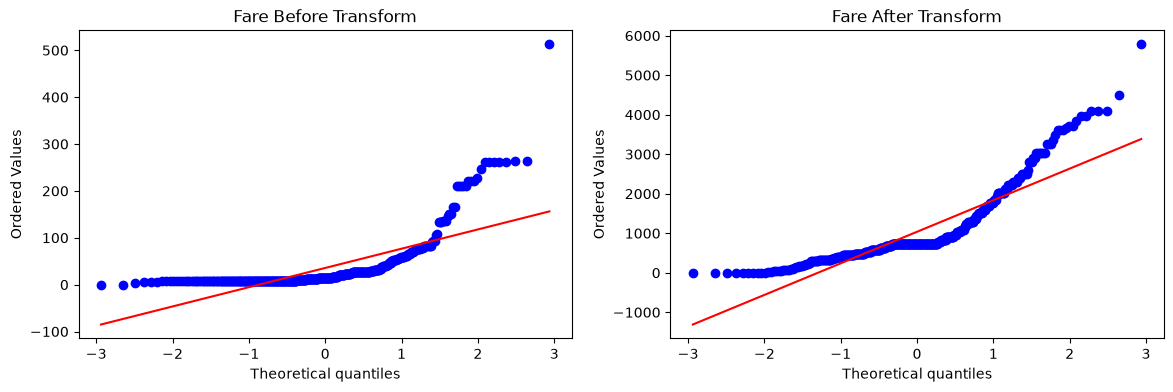

In [42]:
apply_transform(lambda x: x**2)